In [ ]:
pip install kaggle

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d apollo2506/eurosat-dataset

Dataset URL: https://www.kaggle.com/datasets/apollo2506/eurosat-dataset
License(s): CC0-1.0
eurosat-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
import zipfile

with zipfile.ZipFile("eurosat-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("eurosat_data")

In [ ]:
import os

for root, dirs, files in os.walk("eurosat_data"):
    print(root)
    break

eurosat_data


In [ ]:
!pip install kaggle rasterio pyspark

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("EuroSAT NDVI Analysis") \
    .getOrCreate()

In [ ]:
import os

base_path = "eurosat_data/EuroSATallBands"

data = []

for class_name in os.listdir(base_path):
    class_path = os.path.join(base_path, class_name)

    if os.path.isdir(class_path):
        for file in os.listdir(class_path):
            if file.endswith(".tif"):
                data.append((os.path.join(class_path, file), class_name))

print("Total images:", len(data))

Total images: 27597


In [ ]:
rdd = spark.sparkContext.parallelize(data)

In [ ]:
def compute_ndvi(record):
    import rasterio
    import numpy as np

    file_path, label = record

    try:
        ds = rasterio.open(file_path)

        red = ds.read(4).astype(float)
        nir = ds.read(8).astype(float)

        
        if red.max() > 1:
            red = red / 10000.0
            nir = nir / 10000.0

        ndvi = (nir - red) / (nir + red + 1e-10)

        # REMOVE INVALID VALUES
        ndvi = ndvi[np.isfinite(ndvi)]
        ndvi = ndvi[(ndvi >= -1) & (ndvi <= 1)]

        if len(ndvi) == 0:
            return (file_path, label, None)

        return (file_path, label, float(np.median(ndvi)))

    except:
        return (file_path, label, None)

In [ ]:
ndvi_rdd = rdd.map(compute_ndvi)
clean_rdd = ndvi_rdd.filter(lambda x: x[2] is not None)

In [ ]:
df = spark.createDataFrame(clean_rdd, ["Image", "Class", "NDVI"])
df.show(20)

+--------------------+-------------+-------------------+
|               Image|        Class|               NDVI|
+--------------------+-------------+-------------------+
|eurosat_data/Euro...|PermanentCrop| 0.5186927509335281|
|eurosat_data/Euro...|PermanentCrop|0.23484242015590995|
|eurosat_data/Euro...|PermanentCrop|  0.376038373187312|
|eurosat_data/Euro...|PermanentCrop| 0.6191260113022627|
|eurosat_data/Euro...|PermanentCrop|0.20574168044757168|
|eurosat_data/Euro...|PermanentCrop|0.27023018617506905|
|eurosat_data/Euro...|PermanentCrop| 0.5671686989033056|
|eurosat_data/Euro...|PermanentCrop| 0.5990558353009814|
|eurosat_data/Euro...|PermanentCrop| 0.2815812484849798|
|eurosat_data/Euro...|PermanentCrop| 0.5669751368780973|
|eurosat_data/Euro...|PermanentCrop|0.29384570924766085|
|eurosat_data/Euro...|PermanentCrop| 0.2737860462931795|
|eurosat_data/Euro...|PermanentCrop|0.24903291983596315|
|eurosat_data/Euro...|PermanentCrop|0.26987021279335244|
|eurosat_data/Euro...|Permanent

In [ ]:
ndvi_rdd.take(5)

[('eurosat_data/EuroSATallBands/Forest/Forest_1977.tif',
  'Forest',
  0.789099272061093),
 ('eurosat_data/EuroSATallBands/Forest/Forest_114.tif',
  'Forest',
  0.6554520411537588),
 ('eurosat_data/EuroSATallBands/Forest/Forest_248.tif',
  'Forest',
  0.7448077384736114),
 ('eurosat_data/EuroSATallBands/Forest/Forest_125.tif',
  'Forest',
  0.6226710480122182),
 ('eurosat_data/EuroSATallBands/Forest/Forest_315.tif',
  'Forest',
  0.727123726791974)]

In [ ]:
result = df.groupBy("Class") \
           .avg("NDVI") \
           .orderBy("avg(NDVI)", ascending=False)

result.show()

+--------------------+--------------------+
|               Class|           avg(NDVI)|
+--------------------+--------------------+
|              Forest|   0.718214127827991|
|             Pasture|  0.6748015631783771|
|             Highway| 0.47046307937113163|
|HerbaceousVegetation|  0.3861785171734175|
|               River| 0.37105533501401394|
|       PermanentCrop|  0.3705907966883713|
|          AnnualCrop| 0.35350947308151914|
|         Residential| 0.32638621482867197|
|          Industrial| 0.17522047854473521|
|             SeaLake|-0.26096714921696057|
+--------------------+--------------------+



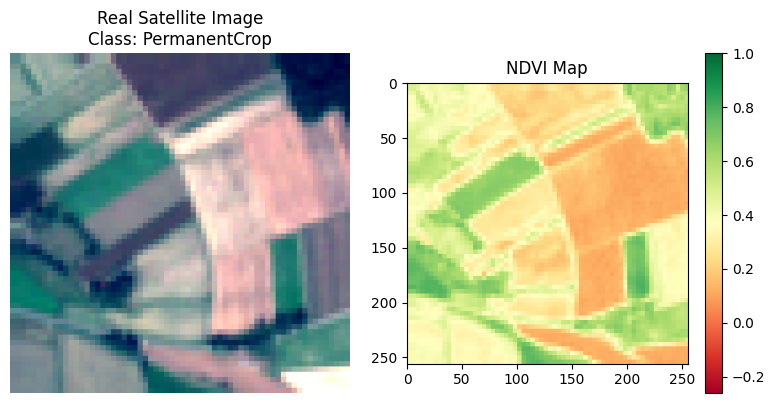

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import cv2

file_path, label = data[2000]

with rasterio.open(file_path) as ds:
    blue = ds.read(2).astype(float)
    green = ds.read(3).astype(float)
    red = ds.read(4).astype(float)
    nir = ds.read(8).astype(float)

if red.max() > 1:
    blue /= 10000.0
    green /= 10000.0
    red /= 10000.0
    nir /= 10000.0

rgb = np.dstack((red, green, blue))

p2, p98 = np.percentile(rgb, (2, 98))
rgb = (rgb - p2) / (p98 - p2 + 1e-10)
rgb = np.clip(rgb, 0, 1)

ndvi = (nir - red) / (nir + red + 1e-10)
ndvi = np.clip(ndvi, -1, 1)

scale_size = 256  

rgb_up = cv2.resize(rgb, (scale_size, scale_size), interpolation=cv2.INTER_NEAREST)
ndvi_up = cv2.resize(ndvi, (scale_size, scale_size), interpolation=cv2.INTER_NEAREST)
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(rgb_up)
plt.title(f"Real Satellite Image\nClass: {label}")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(ndvi_up, cmap='RdYlGn', vmin=-0.26, vmax=1)
plt.title("NDVI Map")
plt.colorbar()

plt.tight_layout()
plt.show()

Selected: eurosat_data/EuroSATallBands/AnnualCrop/AnnualCrop_2377.tif


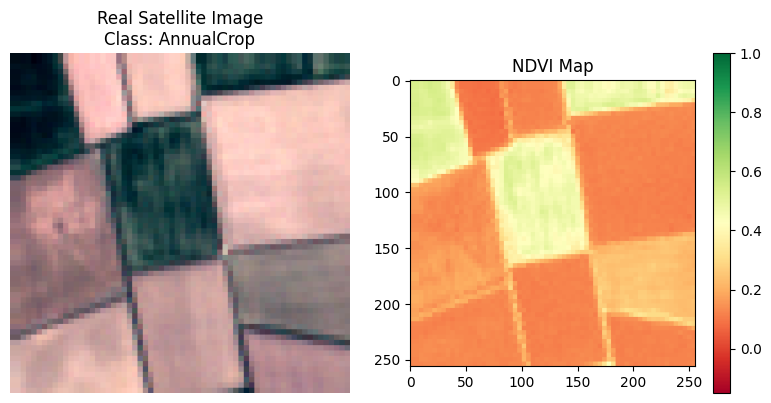

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

selected_class = "AnnualCrop"
image_number = 100

count = 0

for item in data:
    if item[1] == selected_class:
        count += 1
        if count == image_number:
            file_path, label = item
            break

print("Selected:", file_path)

with rasterio.open(file_path) as ds:
    blue = ds.read(2).astype(float)
    green = ds.read(3).astype(float)
    red = ds.read(4).astype(float)
    nir = ds.read(8).astype(float)

if red.max() > 1:
    blue /= 10000.0
    green /= 10000.0
    red /= 10000.0
    nir /= 10000.0

rgb = np.dstack((red, green, blue))

p2, p98 = np.percentile(rgb, (2, 98))
rgb = (rgb - p2) / (p98 - p2 + 1e-10)
rgb = np.clip(rgb, 0, 1)


ndvi = (nir - red) / (nir + red + 1e-10)
ndvi = np.clip(ndvi, -1, 1)

scale_size = 256  

rgb_up = cv2.resize(rgb, (scale_size, scale_size), interpolation=cv2.INTER_NEAREST)
ndvi_up = cv2.resize(ndvi, (scale_size, scale_size), interpolation=cv2.INTER_NEAREST)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(rgb_up)
plt.title(f"Real Satellite Image\nClass: {label}")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(ndvi_up, cmap='RdYlGn', vmin=-0.15, vmax=1)
plt.title("NDVI Map")
plt.colorbar()

plt.tight_layout()
plt.show()

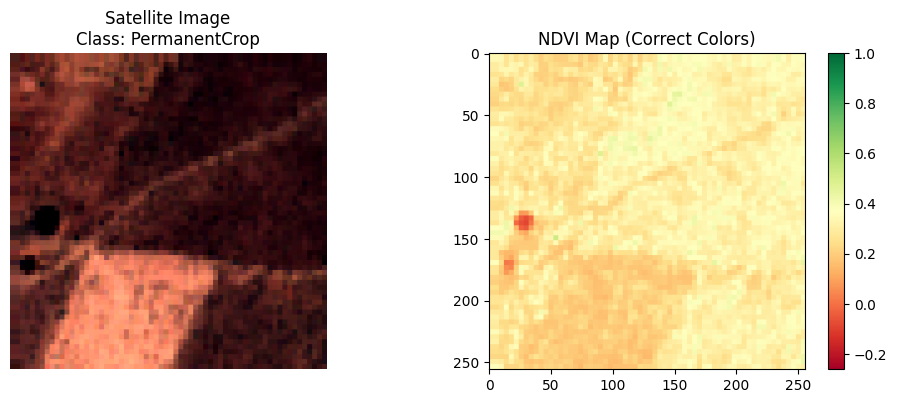

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import cv2

file_path, label = data[500]

with rasterio.open(file_path) as ds:
    blue = ds.read(2).astype(float)
    green = ds.read(3).astype(float)
    red = ds.read(4).astype(float)
    nir = ds.read(8).astype(float)

# Scale
if red.max() > 1:
    blue /= 10000.0
    green /= 10000.0
    red /= 10000.0
    nir /= 10000.0

# RGB
rgb = np.dstack((red, green, blue))
p2, p98 = np.percentile(rgb, (2, 98))
rgb = (rgb - p2) / (p98 - p2 + 1e-10)
rgb = np.clip(rgb, 0, 1)

# NDVI
ndvi = (nir - red) / (nir + red + 1e-10)
ndvi = np.clip(ndvi, -1, 1)

# Upscale (for visibility)
scale = 256
rgb_up = cv2.resize(rgb, (scale, scale), interpolation=cv2.INTER_NEAREST)
ndvi_up = cv2.resize(ndvi, (scale, scale), interpolation=cv2.INTER_NEAREST)


plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(rgb_up)
plt.title(f"Satellite Image\nClass: {label}")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(ndvi_up, cmap='RdYlGn', vmin=-0.26, vmax=1)
plt.title("NDVI Map (Correct Colors)")
plt.colorbar()

plt.tight_layout()
plt.show()


In [ ]:
sample_df = df.sample(fraction=0.1, seed=42)   # 10% data
pdf = sample_df.toPandas()

In [ ]:
rdd = spark.sparkContext.parallelize(data, 8)

sample_rdd = rdd.sample(False, 0.2)

ndvi_rdd = sample_rdd.map(compute_ndvi).cache()

In [ ]:
clean_rdd = ndvi_rdd.filter(lambda x: x[2] is not None)

In [ ]:
df = spark.createDataFrame(clean_rdd, ["Image", "Class", "NDVI"])

In [ ]:
df.cache()
df.count()

5577

In [ ]:
df.groupBy("Class").avg("NDVI").orderBy("avg(NDVI)", ascending=False).show()

+--------------------+--------------------+
|               Class|           avg(NDVI)|
+--------------------+--------------------+
|              Forest|  0.7113503325961641|
|             Pasture|   0.671372588102584|
|             Highway|  0.4741464287207048|
|HerbaceousVegetation|  0.3911064348248983|
|       PermanentCrop| 0.36404161718438927|
|               River| 0.36132809209952255|
|          AnnualCrop|  0.3421745512116199|
|         Residential| 0.32950988975284645|
|          Industrial| 0.17688584916912176|
|             SeaLake|-0.26398312757691256|
+--------------------+--------------------+



In [ ]:
from pyspark.sql.functions import when

ndvi_category_df = df.withColumn(
    "NDVI_Level",
    when(df.NDVI <= 0, "Low")
    .when((df.NDVI > 0) & (df.NDVI <= 0.3), "Medium")
    .otherwise("High")
)

In [ ]:
ndvi_category_df.groupBy("NDVI_Level").count().show()

+----------+-----+
|NDVI_Level|count|
+----------+-----+
|      High| 3102|
|    Medium| 1706|
|       Low|  769|
+----------+-----+



In [ ]:
ndvi_category_df.groupBy("Class", "NDVI_Level").count().show()

+--------------------+----------+-----+
|               Class|NDVI_Level|count|
+--------------------+----------+-----+
|              Forest|      High|  602|
|       PermanentCrop|    Medium|  222|
|       PermanentCrop|      High|  298|
|              Forest|    Medium|    2|
|             SeaLake|       Low|  710|
|          Industrial|    Medium|  448|
|          Industrial|      High|   75|
|             SeaLake|    Medium|   13|
|          Industrial|       Low|    4|
|          AnnualCrop|    Medium|  367|
|          AnnualCrop|      High|  254|
|HerbaceousVegetation|      High|  430|
|HerbaceousVegetation|    Medium|  201|
|HerbaceousVegetation|       Low|    2|
|               River|    Medium|  126|
|               River|       Low|   53|
|               River|      High|  283|
|         Residential|      High|  380|
|         Residential|    Medium|  219|
|             Highway|    Medium|  107|
+--------------------+----------+-----+
only showing top 20 rows


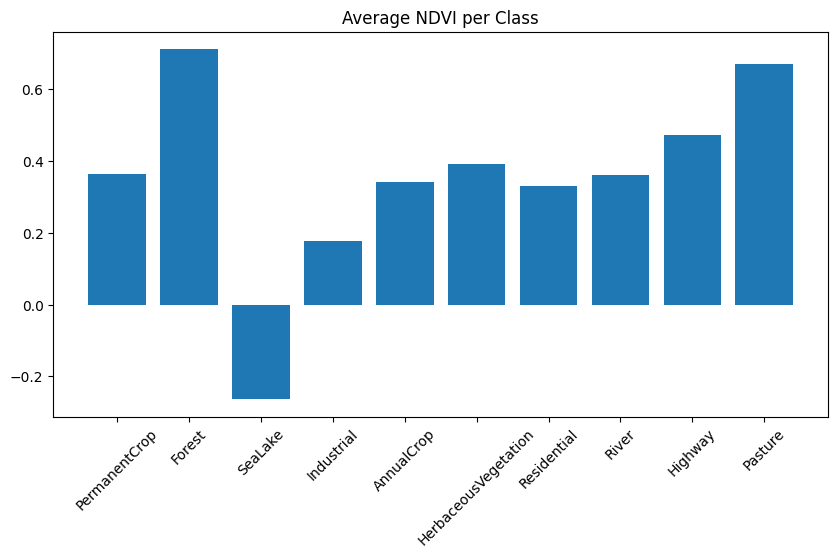

In [ ]:
pdf = df.groupBy("Class").avg("NDVI").toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(pdf["Class"], pdf["avg(NDVI)"])
plt.xticks(rotation=45)
plt.title("Average NDVI per Class")
plt.show()

In [ ]:
df.orderBy("NDVI", ascending=False).show(5)

+--------------------+----------+------------------+
|               Image|     Class|              NDVI|
+--------------------+----------+------------------+
|eurosat_data/Euro...|AnnualCrop|0.8666224282485305|
|eurosat_data/Euro...|AnnualCrop|0.8587657843898646|
|eurosat_data/Euro...|AnnualCrop|0.8571298081228353|
|eurosat_data/Euro...|     River|0.8469764245373983|
|eurosat_data/Euro...|   Pasture|0.8462777678244027|
+--------------------+----------+------------------+
only showing top 5 rows


In [ ]:
df.orderBy("NDVI", ascending=True).show(5)

+--------------------+-------+-------------------+
|               Image|  Class|               NDVI|
+--------------------+-------+-------------------+
|eurosat_data/Euro...|SeaLake|-0.5791925461341673|
|eurosat_data/Euro...|SeaLake|-0.5763888883885513|
|eurosat_data/Euro...|SeaLake| -0.570358034495955|
|eurosat_data/Euro...|SeaLake|-0.5698744765105653|
|eurosat_data/Euro...|SeaLake|-0.5667429438850169|
+--------------------+-------+-------------------+
only showing top 5 rows


# Full Dataset

In [ ]:
rdd = spark.sparkContext.parallelize(data, 8)

In [ ]:
ndvi_rdd = rdd.map(compute_ndvi).cache()

In [ ]:
clean_rdd = ndvi_rdd.filter(lambda x: x[2] is not None)

In [ ]:
df = spark.createDataFrame(clean_rdd, ["Image", "Class", "NDVI"])

In [ ]:
df.cache()
df.count()

27597

In [ ]:
df.groupBy("Class").avg("NDVI").orderBy("avg(NDVI)", ascending=False).show()

+--------------------+--------------------+
|               Class|           avg(NDVI)|
+--------------------+--------------------+
|              Forest|   0.718214127827991|
|             Pasture|  0.6748015631783771|
|             Highway|  0.4704630793711317|
|HerbaceousVegetation|  0.3861785171734185|
|               River| 0.37105533501401394|
|       PermanentCrop| 0.37059079668837147|
|          AnnualCrop| 0.35350947308151914|
|         Residential| 0.32638621482867164|
|          Industrial|  0.1752204785447356|
|             SeaLake|-0.26096714921695985|
+--------------------+--------------------+



In [ ]:
from pyspark.sql.functions import when

ndvi_category_df = df.withColumn(
    "NDVI_Level",
    when(df.NDVI <= 0, "Low")
    .when((df.NDVI > 0) & (df.NDVI <= 0.3), "Medium")
    .otherwise("High")
)

ndvi_category_df.groupBy("NDVI_Level").count().show()

+----------+-----+
|NDVI_Level|count|
+----------+-----+
|      High|15481|
|    Medium| 8294|
|       Low| 3822|
+----------+-----+



In [ ]:
df.write.csv("final_ndvi_results", header=True)

In [ ]:
import shutil

shutil.make_archive("ndvi_results", 'zip', "final_ndvi_results")

'/content/ndvi_results.zip'

In [ ]:
from google.colab import files
files.download("ndvi_results.zip")

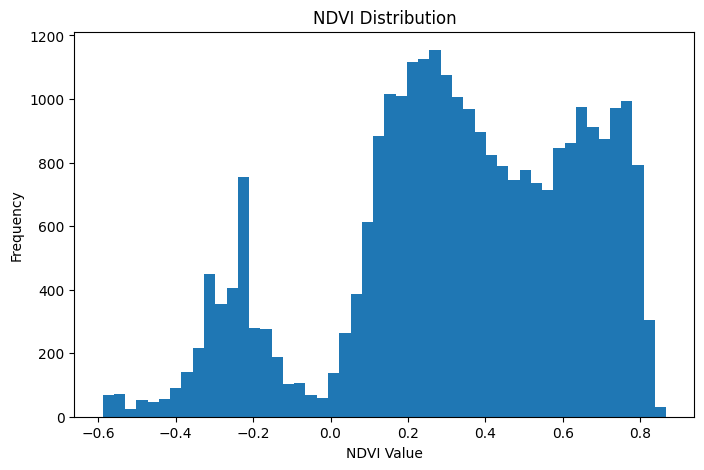

In [ ]:
pdf = df.select("NDVI").toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(pdf["NDVI"], bins=50)
plt.title("NDVI Distribution")
plt.xlabel("NDVI Value")
plt.ylabel("Frequency")
plt.show()

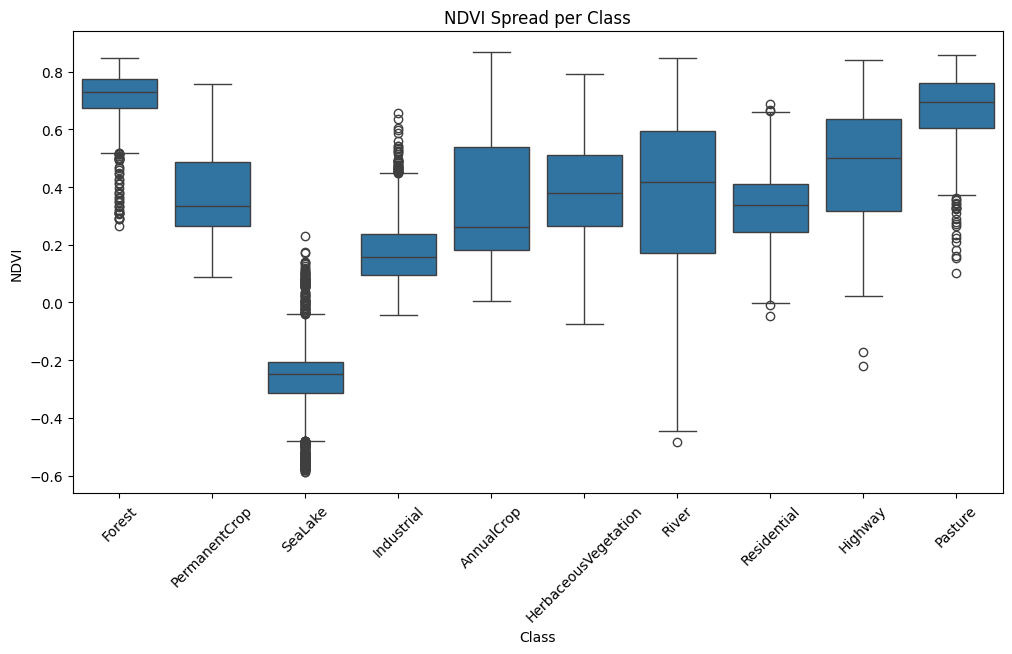

In [ ]:
pdf = df.toPandas()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.boxplot(x="Class", y="NDVI", data=pdf)
plt.xticks(rotation=45)
plt.title("NDVI Spread per Class")
plt.show()

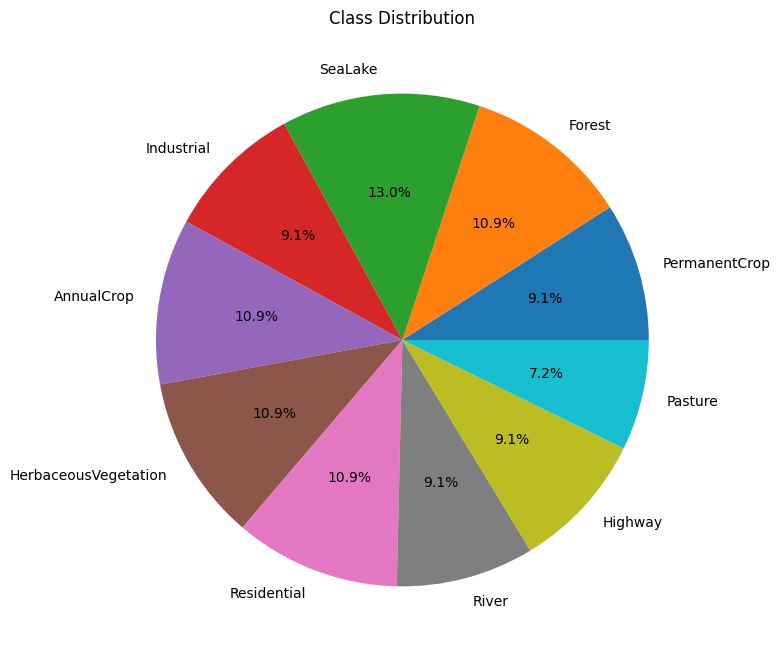

In [ ]:
pdf2 = df.groupBy("Class").count().toPandas()

plt.figure(figsize=(8,8))
plt.pie(pdf2["count"], labels=pdf2["Class"], autopct='%1.1f%%')
plt.title("Class Distribution")
plt.show()

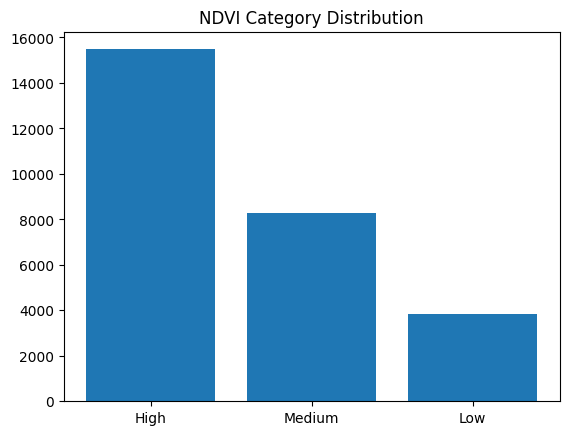

In [ ]:
pdf3 = ndvi_category_df.groupBy("NDVI_Level").count().toPandas()

plt.bar(pdf3["NDVI_Level"], pdf3["count"])
plt.title("NDVI Category Distribution")
plt.show()

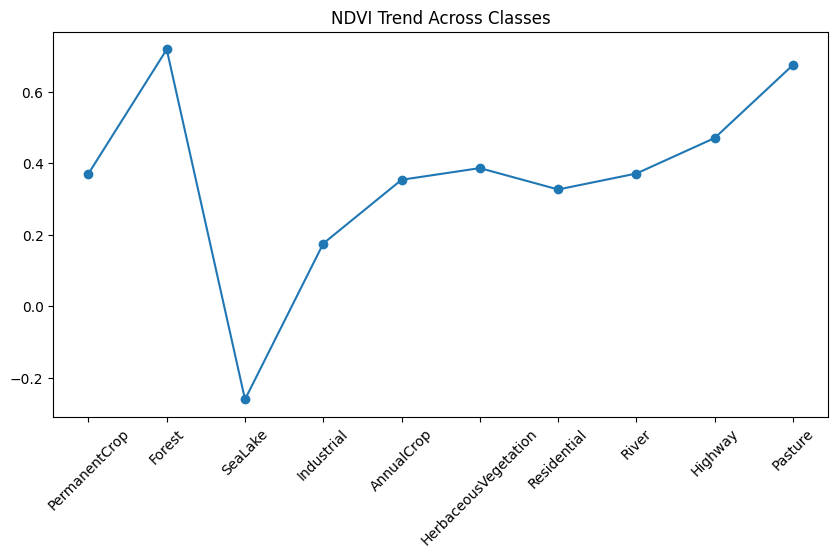

In [ ]:
pdf4 = df.groupBy("Class").avg("NDVI").toPandas()

plt.figure(figsize=(10,5))
plt.plot(pdf4["Class"], pdf4["avg(NDVI)"], marker='o')
plt.xticks(rotation=45)
plt.title("NDVI Trend Across Classes")
plt.show()

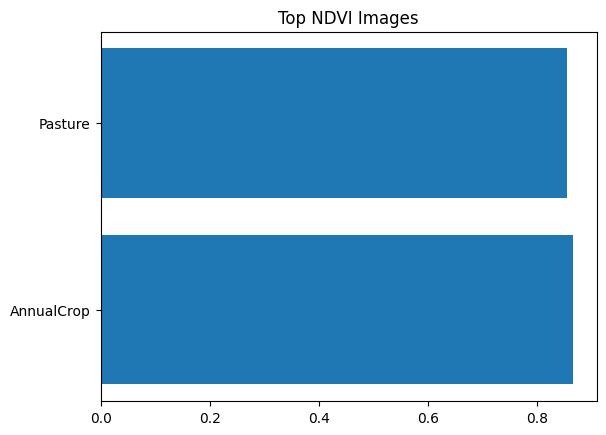

In [ ]:
top = df.orderBy("NDVI", ascending=False).limit(10).toPandas()
bottom = df.orderBy("NDVI", ascending=True).limit(10).toPandas()

plt.barh(top["Class"], top["NDVI"])
plt.title("Top NDVI Images")
plt.show()

In [ ]:
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import shutil

output_base = "/content/ndvi_dataset"
rgb_folder = os.path.join(output_base, "rgb")
ndvi_folder = os.path.join(output_base, "ndvi")

os.makedirs(rgb_folder, exist_ok=True)
os.makedirs(ndvi_folder, exist_ok=True)

def process_and_save(file_path, label, idx):
    try:
        with rasterio.open(file_path) as ds:
            blue = ds.read(2).astype(float)
            green = ds.read(3).astype(float)
            red = ds.read(4).astype(float)
            nir = ds.read(8).astype(float)

        if red.max() > 1:
            blue /= 10000.0
            green /= 10000.0
            red /= 10000.0
            nir /= 10000.0

        rgb = np.dstack((red, green, blue))
        p2, p98 = np.percentile(rgb, (2, 98))
        rgb = (rgb - p2) / (p98 - p2 + 1e-10)
        rgb = np.clip(rgb, 0, 1)

        ndvi = (nir - red) / (nir + red + 1e-10)
        ndvi = np.clip(ndvi, -1, 1)

        base_name = os.path.splitext(os.path.basename(file_path))[0]

        rgb_path = os.path.join(rgb_folder, f"{base_name}.png")
        plt.imsave(rgb_path, rgb)

        ndvi_path = os.path.join(ndvi_folder, f"{base_name}_ndvi.png")
        plt.imsave(ndvi_path, ndvi, cmap='RdYlGn', vmin=-0.26, vmax=1)

    except Exception as e:
        print(f"Error in {file_path}: {e}")

for i, (file_path, label) in enumerate(tqdm(data)):
    process_and_save(file_path, label, i)

print("All images processed!")

zip_path = "/content/ndvi_dataset.zip"
shutil.make_archive("/content/ndvi_dataset", 'zip', output_base)

print("ZIP file created!")
print("Download from:", zip_path)

100%|██████████| 27597/27597 [04:26<00:00, 103.62it/s]


All images processed!
ZIP file created!
Download from: /content/ndvi_dataset.zip


In [ ]:
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import shutil

output_base = "/content/ndvi_dataset"
rgb_folder = os.path.join(output_base, "rgb")
ndvi_folder = os.path.join(output_base, "ndvi")

os.makedirs(rgb_folder, exist_ok=True)
os.makedirs(ndvi_folder, exist_ok=True)

def process_and_save(file_path, label, idx):
    try:
        with rasterio.open(file_path) as ds:
            blue = ds.read(2).astype(float)
            green = ds.read(3).astype(float)
            red = ds.read(4).astype(float)
            nir = ds.read(8).astype(float)

        if red.max() > 1:
            blue /= 10000.0
            green /= 10000.0
            red /= 10000.0
            nir /= 10000.0

        rgb = np.dstack((red, green, blue))
        p2, p98 = np.percentile(rgb, (2, 98))
        rgb = (rgb - p2) / (p98 - p2 + 1e-10)
        rgb = np.clip(rgb, 0, 1)

        
        ndvi = (nir - red) / (nir + red + 1e-10)
        ndvi = np.clip(ndvi, -1, 1)

        rgb_class_folder = os.path.join(rgb_folder, label)
        ndvi_class_folder = os.path.join(ndvi_folder, label)

        os.makedirs(rgb_class_folder, exist_ok=True)
        os.makedirs(ndvi_class_folder, exist_ok=True)

        base_name = os.path.splitext(os.path.basename(file_path))[0]

        rgb_path = os.path.join(rgb_class_folder, f"{base_name}.png")
        plt.imsave(rgb_path, rgb)

        ndvi_path = os.path.join(ndvi_class_folder, f"{base_name}_ndvi.png")
        plt.imsave(ndvi_path, ndvi, cmap='RdYlGn', vmin=-0.26, vmax=1)

    except Exception as e:
        print(f"Error in {file_path}: {e}")

for i, (file_path, label) in enumerate(tqdm(data)):
    process_and_save(file_path, label, i)

print("All images processed!")

zip_path = "/content/ndvi_dataset.zip"
shutil.make_archive("/content/ndvi_dataset", 'zip', output_base)

print("ZIP file created!")
print("Download from:", zip_path)

from google.colab import files
files.download(zip_path)


100%|██████████| 27597/27597 [04:03<00:00, 113.34it/s]


All images processed!
ZIP file created!
Download from: /content/ndvi_dataset.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>